## EXPLORATORY DATA ANALYSIS OF IMAGES

#### 1- Importing the library

In [1]:
import os
import sys, logging, pathlib
import matplotlib.pyplot as plt
import numpy as np
%pip install pillow


Note: you may need to restart the kernel to use updated packages.


In [2]:
%ls

01_data_ingestion.ipynb  02_data_eda.ipynb  FaceImages.zip  trials.ipynb


In [3]:
%pwd

'/home/donerick/FaceSystemRecognition-DeepFake-/research'

In [4]:
os.chdir("../")

In [5]:
%pwd

'/home/donerick/FaceSystemRecognition-DeepFake-'

#### Labelisation des images

In [9]:
from Face_Recognition_System import logger
import pandas as pd
data_path = pathlib.Path('artifacts/Human_Faces')
categories = {"Real_Images":0, "AI_Generated_Images":1}

def labelize_image(path_to_data: pathlib.Path):
    data = []
    for category, label in categories.items():
        folder_path = path_to_data / category
        
        # On liste tous les fichiers images
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
        for img_name in images:
            # On stocke le chemin relatif et le label
            data.append({
                'image_path': os.path.join(path_to_data, category, img_name),
                'label': label,
                'category': category
            })

    # 3. Création du DataFrame et sauvegarde en CSV
    df = pd.DataFrame(data)

    # Mélanger les données
    df = df.sample(frac=1).reset_index(drop=True) 

    # output csv file
    output_data_csv = 'artifacts/dataset_metadata.csv'
    df.to_csv(output_data_csv, index=False)
    logger.info(f"✅ Fichier CSV créé avec {len(df)} entrées in :{output_data_csv}")
    return df

if __name__=="__main__":
    df = labelize_image(data_path)
    df['category'].value_counts()

[2026-01-22 16:59:51,311: INFO: 2866685746: ✅ Fichier CSV créé avec 9630 entrées in :artifacts/dataset_metadata.csv]


### Display images

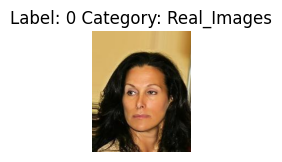

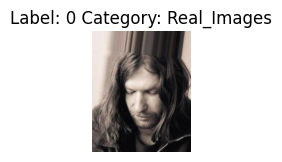

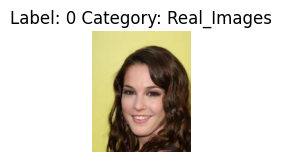

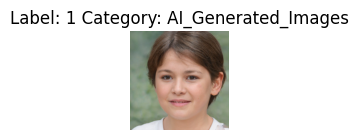

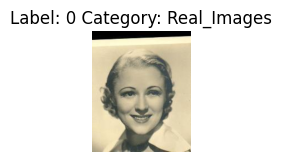

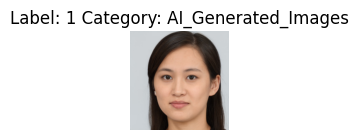

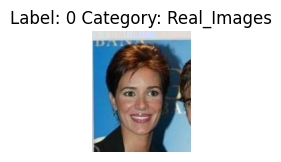

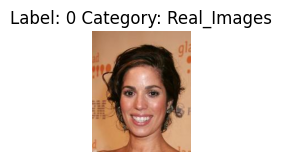

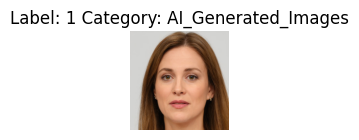

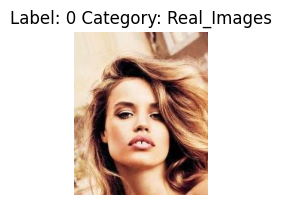

In [14]:
import matplotlib.pyplot as mpimg
from PIL import Image

def display_images(image_path: pathlib.Path,
                n_samples=10):
    samples = image_path.sample(n=n_samples).reset_index(drop=True)
    for i, (index, row) in enumerate(samples.iterrows()):
        plt.figure(figsize=(15, 6))
        plt.subplot(1, n_samples, i+1)
        img = mpimg.imread(row['image_path'])
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Label: {row['label']} Category: {row['category']}")

    plt.tight_layout()
    plt.show()


display_images(df, n_samples=10)
    